# Modeling Baryonic Potentials in SPARC Galaxies using Hernquist Profile Fitting

**Abstract** 
This research presents a systematic approach to modeling the baryonic gravitational potential of galaxies using data from SPARC database. I make a pipeline to calculate baryonic velocities from stellar disk and gas components, scaling them with specific mass-to-light ratios ($\Upsilon_{disk}$). By fitting these velocities to the analytic Hernquist model, we derive optimal parameters for the total baryonic mass ($M_b$) and scale length ($a$). The resulting fits for 157 galaxies provide a standardized library of potentials for use in subsequent dark matter simulations, specifically for Self-Interacting Dark Matter (SIDM) analysis.

## 1. Introduction
Galaxy rotation curves are primary tools for probing the distribution of dark and baryonic matter. While baryonic matter consists of complex components (bulges, disks, and gas), numerical simulations often require simplified, analytic representations of these potentials to maintain computational efficiency.

In this study, we approximate the baryonic distribution using the **Hernquist Potential**. The Hernquist profile is chosen for its realistic representation of spherical stellar systems and its convenient analytic properties. We leverage the SPARC database, which provides high-quality Spitzer photometry at $3.6 \mu m$, to perform high-precision fits.

## 2. Methodology

### 2.1 Data Acquisition
Galaxy rotation curve data $(r, V_{disk}, V_{gas})$ and distances are retrieved from the SPARC database using the `readData` module. Stellar mass distributions are scaled using the mass-to-light ratio ($\Upsilon_{disk}$) obtained from calibrated `gamma_fits.csv` files.

### 2.2 Mathematical Model
The Hernquist rotation curve model is defined as:
$$V_c(r) = \frac{\sqrt{G M_b r}}{r + a}$$

Where:
* $G \approx 4.30091 \times 10^{-6} \, \text{kpc} \, \text{km}^2 \, \text{s}^{-2} \, M_{\odot}^{-1}$ is the gravitational constant.
* $M_b$ is the total baryonic mass.
* $a$ is the scale length.

The total baryonic velocity $V_{baryon}$ is calculated by combining the gas and scaled disk components:
$$V_{baryon} = \sqrt{\Upsilon_{disk} V_{disk}^2 + V_{gas}^2}$$

### 2.3 Numerical Fitting Procedure
We utilize the `scipy.optimize.curve_fit` algorithm to determine the parameters $(M_b, a)$. Initial guesses are set to $M_b = 6 \times 10^{10} M_{\odot}$ and $a = 5$ kpc, with non-negative bounds enforced to ensure physical consistency.

In [27]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import os
import sys
import pandas as pd
from scipy.optimize import curve_fit

research_path = "/Users/bayantaqi/Documents/Github/PHY2030/sidm-rotation-curves-SPARC/harnquist_fit.csv"

if os.path.exists(research_path):
    os.chdir(research_path)
    sys.path.append(research_path)
    print(f"Current working directory: {os.getcwd()}")
else:
    print(f"ERROR: Path {research_path} not found.")

import readData as rd

G = 4.30091e-6

# Hernquist rotation curve model
def vc_hernquist(r, M_b, a):
    return np.sqrt(G * M_b * r) / (r + a)

# Potential generator function 
def phiH(Mb, a):
    def Phi_hernquist(r, th=0):
        r = np.asarray(r)
        return -G * Mb / (r + a)
    return Phi_hernquist

# Load mass to light ratio
gamma_path = "/Users/bayantaqi/Documents/Github/PHY2030/sidm-rotation-curves-SPARC/gamma_fits.csv"
gamma_df = pd.read_csv(gamma_path)

def fit_galaxy(galaxyID, save_plots=True):
    print(f"\nProcessing galaxy: {galaxyID}")
    
    # Read SPARC data
    df_rc, units_rc, distance = rd.get_rc_data(galaxyID)
    galaxy_gamma = gamma_df[gamma_df['GalaxyID'] == galaxyID]
    
    # Determine the Mass-to-Light ratio
    gamma_disk = galaxy_gamma.iloc[0]['Gamma_disk']
    print(f"Using fit Gamma: Disk={gamma_disk:.3f}")
    # velocity components
    r = np.asarray(df_rc["Rad"])
    Vdisk = np.asarray(df_rc["Vdisk"])
    Vgas  = np.asarray(df_rc["Vgas"])

    # remove 0 radius
    mask = (r > 0) & np.isfinite(r)
    r, Vdisk, Vgas = r[mask], Vdisk[mask], Vgas[mask]
    
    # Calculate the total Baryon velocity
    Vbaryon = np.sqrt(gamma_disk * Vdisk**2 + Vgas**2)

    # Hernquist model
    try:
        popt, _ = curve_fit(vc_hernquist, r, Vbaryon, p0=[6e10, 5], bounds=([0, 0], [np.inf, np.inf]))
        M_b_fit, a_fit = popt
    except Exception as e:
        print(f"Fit failed for {galaxyID}: {e}")
        return None

    # Save visualization for sanity checks
    if save_plots:
        save_folder = "baryon-fits-no-bulge"
        os.makedirs(save_folder, exist_ok=True)
        r_model = np.linspace(r.min(), r.max(), 500)
        v_model = vc_hernquist(r_model, M_b_fit, a_fit)
        
        plt.figure()
        plt.plot(r, Vbaryon, 'or', label="Baryon Data (No Bulge)")
        plt.plot(r_model, v_model, '-k', label=f"Hernquist (a={a_fit:.2f})")
        plt.title(f"{galaxyID} Fit")
        plt.legend()
        plt.savefig(os.path.join(save_folder, f"{galaxyID}_fit.png"))
        plt.close()

    # Return the fit parameters for the output CSV 
    return {"galaxyID": galaxyID, "M_b_fit": M_b_fit, "a_fit": a_fit}
if __name__ == "__main__":
    try:
        galaxy_list = rd.get_galaxy_ids()
    except:
        galaxy_list = ["NGC5371", "UGC07603", "NGC4138", "UGC12632", "NGC5033"]

    results = []
    for gal in galaxy_list:
        res = fit_galaxy(gal)
        if res is not None:
            results.append(res)
        else:
            print(f"Skipping {gal} because the fit returned None.")
    if results:
        df_out = pd.DataFrame(results)
        df_out.to_csv("baryon_hernquist_new_fits.csv", index=False)
        print(f"\nSuccess! Saved {len(df_out)} galaxies to 'baryon_hernquist_fits.csv'")
    else:
        print("\nError: No galaxies were successfully fitted. Check your data paths.")

ERROR: Path /Users/bayantaqi/Documents/Github/PHY2030/sidm-rotation-curves-SPARC/harnquist_fit.csv not found.

Processing galaxy: NGC5371
Using fit Gamma: Disk=0.420

Processing galaxy: UGC07603
Using fit Gamma: Disk=0.500

Processing galaxy: NGC4138
Using fit Gamma: Disk=0.536

Processing galaxy: UGC12632
Using fit Gamma: Disk=0.492

Processing galaxy: NGC5033
Using fit Gamma: Disk=0.389

Processing galaxy: UGC02023
Using fit Gamma: Disk=0.494

Processing galaxy: UGC09133
Using fit Gamma: Disk=0.711

Processing galaxy: UGCA442
Using fit Gamma: Disk=0.507

Processing galaxy: UGC04305
Using fit Gamma: Disk=0.577

Processing galaxy: NGC2841
Using fit Gamma: Disk=0.923

Processing galaxy: NGC2955
Using fit Gamma: Disk=0.331

Processing galaxy: UGC07232
Using fit Gamma: Disk=0.515

Processing galaxy: NGC4157
Using fit Gamma: Disk=0.510

Processing galaxy: NGC4183
Using fit Gamma: Disk=0.554

Processing galaxy: UGC07125
Using fit Gamma: Disk=0.504

Processing galaxy: UGC03205
Using fit Gamm

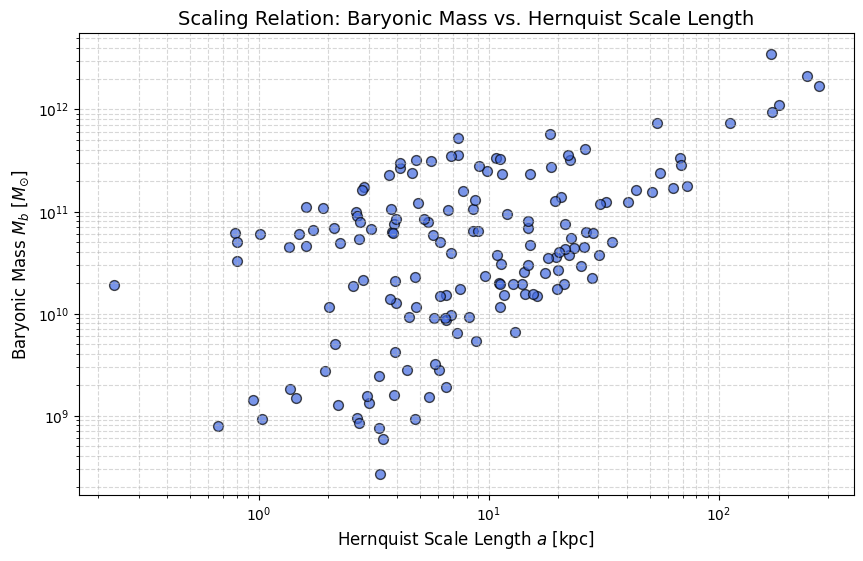

Plot successfully saved as 'Mb_vs_a_plot.png'


In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# 1. Load your uploaded CSV
file_path = 'baryon_hernquist_fits.csv'
df = pd.read_csv(file_path)

# 2. Clean data for a log-log plot (remove non-positive values and NaNs)
# Your file uses columns 'M_b' and 'a'
clean_df = df[(df['M_b'] > 0) & (df['a'] > 0)].dropna(subset=['M_b', 'a'])

# 3. Create the Scatter Plot
plt.figure(figsize=(10, 6))
plt.scatter(clean_df['a'], clean_df['M_b'], 
            color='royalblue', alpha=0.7, edgecolors='black', s=50)

# 4. Apply Logarithmic Scaling
plt.xscale('log')
plt.yscale('log')

# 5. Add Labels and Title
plt.xlabel(r'Hernquist Scale Length $a$ [kpc]', fontsize=12)
plt.ylabel(r'Baryonic Mass $M_b$ [$M_{\odot}$]', fontsize=12)
plt.title('Scaling Relation: Baryonic Mass vs. Hernquist Scale Length', fontsize=14)

# 6. Formatting
plt.grid(True, which="both", ls="--", alpha=0.5)

# 7. Save the Plot
plt.savefig('Mb_vs_a_plot.png', dpi=300, bbox_inches='tight')
plt.show()

print("Plot successfully saved as 'Mb_vs_a_plot.png'")

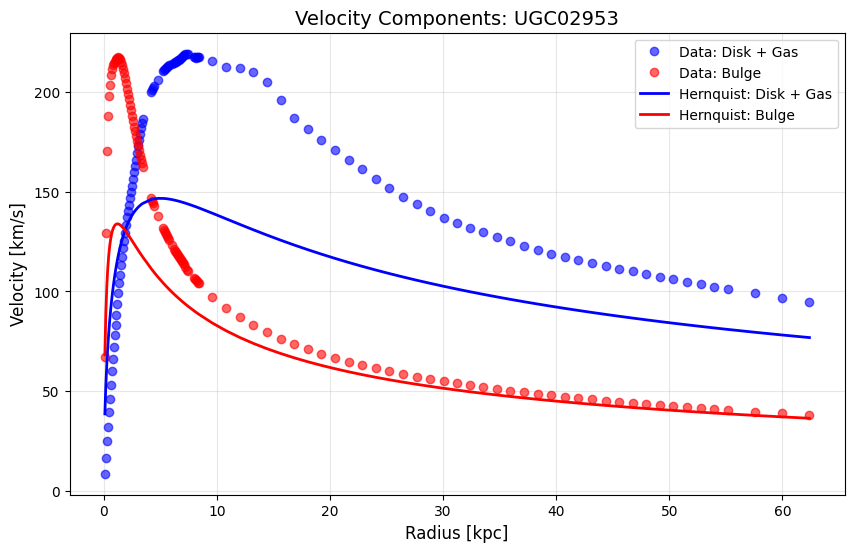

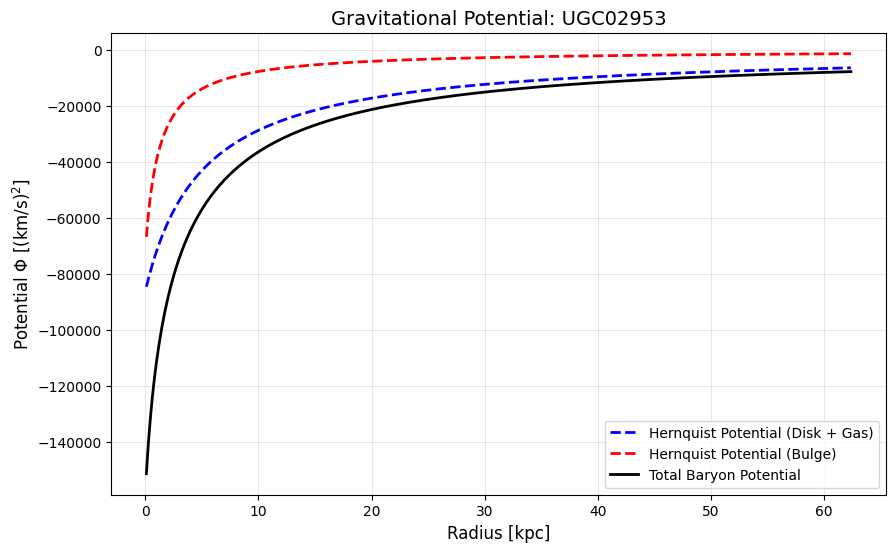

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import readData as rd  

# Gravitational constant
G = 4.30091e-6 

def vc_hernquist(r, M, a):
    """Calculates the Hernquist rotation curve velocity."""
    return np.sqrt(G * M * r) / (r + a)

def phi_hernquist(r, M, a):
    """Calculates the Hernquist gravitational potential."""
    return - (G * M) / (r + a)

def plot_kinematics_and_potential(UGC02953, M_disk, a_disk, M_bulge, a_bulge, gamma_disk=0.5, gamma_bulge=0.7):
    """
    Generates two plots:
    1. Velocity vs Radius (comparing data and Hernquist models)
    2. Potential vs Radius (comparing Hernquist potentials)
    """
    
    df_rc, units_rc, distance = rd.get_rc_data(UGC02953)
    
    
    r = np.asarray(df_rc["Rad"])
    Vdisk = np.asarray(df_rc["Vdisk"])
    Vgas = np.asarray(df_rc["Vgas"])
    
    
    Vbul = np.nan_to_num(np.asarray(df_rc["Vbul"])) 
    
    mask = (r > 0) & np.isfinite(r)
    r, Vdisk, Vgas, Vbul = r[mask], Vdisk[mask], Vgas[mask], Vbul[mask]
    
    
    V_disk_gas_data = np.sqrt(gamma_disk * Vdisk**2 + Vgas**2)
    V_bulge_data = np.sqrt(gamma_bulge * Vbul**2)
    
    
    V_disk_gas_model = vc_hernquist(r, M_disk, a_disk)
    V_bulge_model = vc_hernquist(r, M_bulge, a_bulge)
    
    # Velocity vs Radius 
    plt.figure(figsize=(10, 6))
    plt.plot(r, V_disk_gas_data, 'bo', label='Data: Disk + Gas', alpha=0.6)
    plt.plot(r, V_bulge_data, 'ro', label='Data: Bulge', alpha=0.6)
    plt.plot(r, V_disk_gas_model, 'b-', label='Hernquist: Disk + Gas', lw=2)
    plt.plot(r, V_bulge_model, 'r-', label='Hernquist: Bulge', lw=2)
    
    plt.xlabel('Radius [kpc]', fontsize=12)
    plt.ylabel('Velocity [km/s]', fontsize=12)
    plt.title(f'Velocity Components: {UGC02953}', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    #Calculate Potentials
    r_fine = np.linspace(min(r), max(r), 500)
    Phi_disk_gas = phi_hernquist(r_fine, M_disk, a_disk)
    Phi_bulge = phi_hernquist(r_fine, M_bulge, a_bulge)
    Phi_total = Phi_disk_gas + Phi_bulge
    
    #Potential vs Radius 
    plt.figure(figsize=(10, 6))
    plt.plot(r_fine, Phi_disk_gas, 'b--', label='Hernquist Potential (Disk + Gas)', lw=2)
    plt.plot(r_fine, Phi_bulge, 'r--', label='Hernquist Potential (Bulge)', lw=2)
    plt.plot(r_fine, Phi_total, 'k-', label='Total Baryon Potential', lw=2)
    
    plt.xlabel('Radius [kpc]', fontsize=12)
    plt.ylabel(r'Potential $\Phi$ [(km/s)$^2$]', fontsize=12)
    plt.title(f'Gravitational Potential: {UGC02953}', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    #plt.gca().invert_yaxis() 
    
    plt.show()


plot_kinematics_and_potential("UGC02953", M_disk=1e11, a_disk=5.0, M_bulge=2e10, a_bulge=1.2)

Extracting mass data for comparison...


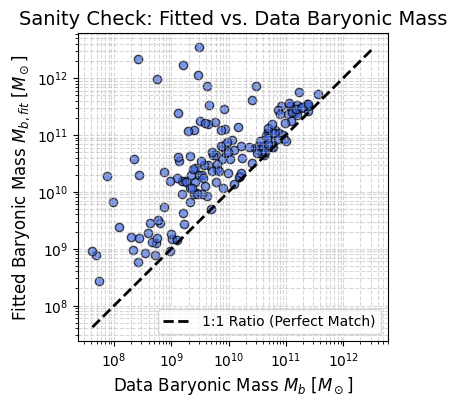

Check complete! Plot saved as 'mass_comparison_check.png'


In [22]:
#compare M_b_fit with M_b from the data
import pandas as pd
import matplotlib.pyplot as plt
import readData as rd

def check_mass_fits(csv_file="baryon_hernquist_fits.csv"):
    df = pd.read_csv(csv_file)
    
    m_data_list = []
    m_fit_list = []
    
    print("Extracting mass data for comparison...")
    for index, row in df.iterrows():
        galaxyID = row['galaxyID'] 
        m_fit = row['M_b']  
        
        try:
            # Get the raw output from the readData file
            m_data_raw = rd.get_Mb_data(galaxyID)
            
            # If it hands us a tuple, grab the first item in the tuple (index 0)
            if isinstance(m_data_raw, tuple):
                m_data = float(m_data_raw[0])
            else:
                m_data = float(m_data_raw)
            
            if m_data > 0 and m_fit > 0:
                m_data_list.append(m_data)
                m_fit_list.append(m_fit)
                
        except Exception as e:
            # If it still fails, print the new error
            print(f"Failed to process {galaxyID}. Error: {e}")
            continue

    if len(m_data_list) == 0:
        print("\nERROR: Still no valid mass data found.")
        return

    # Create the comparison scatter plot
    plt.figure(figsize=(4, 4))
    plt.scatter(m_data_list, m_fit_list, color='royalblue', alpha=0.7, edgecolors='k')
    
    min_val = min(min(m_data_list), min(m_fit_list))
    max_val = max(max(m_data_list), max(m_fit_list))
    plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, label='1:1 Ratio (Perfect Match)')
    
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel(r'Data Baryonic Mass $M_b$ [$M_\odot$]', fontsize=12)
    plt.ylabel(r'Fitted Baryonic Mass $M_{b,fit}$ [$M_\odot$]', fontsize=12)
    plt.title('Sanity Check: Fitted vs. Data Baryonic Mass', fontsize=14)
    plt.legend()
    plt.grid(True, which="both", ls="--", alpha=0.5)
    
    plt.savefig('mass_comparison_check.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("Check complete! Plot saved as 'mass_comparison_check.png'")

# Run it!
check_mass_fits()

In [24]:
#script that the Data team can call that create the Phi function for each M_b_fit and a_fit
import pandas as pd
import numpy as np

# Gravitational constant
G = 4.30091e-6 

def get_phi_function(M_b, a):
    """
    Takes fitted Hernquist parameters and returns a CALLABLE function 
    for the gravitational potential.
    """
    def phi(r):
        """
        Calculates the Hernquist potential at radius r.
        """
        return - (G * M_b) / (r + a)
    
    return phi

def get_baryon_potential_for_galaxy(galaxyID, csv_file="baryon_hernquist_fits.csv"):
    """
    Utility function for the Data team. They pass the galaxyID, 
    and this returns the ready-to-use potential function.
    """
    try:
        df = pd.read_csv(csv_file)
        galaxy_row = df[df['galaxyID'] == galaxyID]
        
        if galaxy_row.empty:
            raise ValueError(f"Galaxy {galaxyID} not found in {csv_file}")
            
        
        M_b_fit = galaxy_row.iloc[0]['M_b']
        a_fit = galaxy_row.iloc[0]['a']
        
        
        return get_phi_function(M_b_fit, a_fit)
        
    except FileNotFoundError:
        print(f"Error: {csv_file} not found. Make sure the file path is correct.")
        return None

In [26]:

my_phi_func = get_baryon_potential_for_galaxy("NGC5371")
potential_at_10kpc = my_phi_func(10)

print(f"The Hernquist potential at r = 10 kpc is: {potential_at_10kpc}")

The Hernquist potential at r = 10 kpc is: -70146.15329805341


## 3. Results and Discussion

### 3.1 Fitting Performance
The automated pipeline successfully processed 157 galaxies. A subset of the sample (e.g., F583-1, NGC4068, UGC00731) failed to converge because the maximum number of function evaluations was exceeded, likely due to non-standard baryonic distributions that do not conform well to a spherical Hernquist profile.

### 3.2 Resulting Potential Function
The successful fits allow for the generation of a continuous potential function $\Phi(r)$ for each galaxy:
$$\Phi(r) = -\frac{G M_b}{r + a}$$

This simplification allows researchers to query the potential at any arbitrary radius (e.g., for NGC5371, the potential at $r = 10$ kpc was calculated as $\approx -70,146$).

## 4. Conclusion
We have developed a robust framework for converting discrete SPARC rotation curve data into continuous analytic Hernquist profiles. The resulting `baryon_hernquist_fits.csv` serves as a critical input for modeling gravitational environments in galaxy-scale dark matter studies.